In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Choose directory
directory = "C:/Users/Fede/OneDrive/Projects/prorindes"
os.chdir(directory)

In [2]:
from Scripts.functions_plots import * 

In [3]:
data_in = "data/raw_data/"
data_out = "data/processed_data/"
files_plots = "plots/"

# Import file

In [4]:
file = data_in + "yield_cleaned.csv"
df = pd.read_csv(file)
df.head()

,crop,location,wmm_id,longitude,latitude,soil_series,soil_family,soil_prop,initial_sw,management,year,yield_kg_ha
0,WH,Coronel Suárez,87637,-61.88,-37.43,La Carolina,Hapludol típico,0.5,low,Intermedio-Largo - 25 Jun - 140N,1961,3745
1,WH,Coronel Suárez,87637,-61.88,-37.43,La Carolina,Hapludol típico,0.5,mid,Intermedio-Largo - 25 Jun - 140N,1961,4409
2,WH,Coronel Suárez,87637,-61.88,-37.43,La Carolina,Hapludol típico,0.5,high,Intermedio-Largo - 25 Jun - 140N,1961,4702
3,WH,Coronel Suárez,87637,-61.88,-37.43,La Carolina,Hapludol típico,0.5,low,Intermedio-Corto - 25 Jul - 140N,1961,3770
4,WH,Coronel Suárez,87637,-61.88,-37.43,La Carolina,Hapludol típico,0.5,mid,Intermedio-Corto - 25 Jul - 140N,1961,4428


# Create unique location information

In [5]:
data_locations = df.groupby(["location","wmm_id","latitude","longitude"])["year"].mean().reset_index()

data_locations = data_locations.drop(columns="year")
# Save the data
data_locations.to_csv(  data_out + "location_info.csv",index=False)

### Map of locations

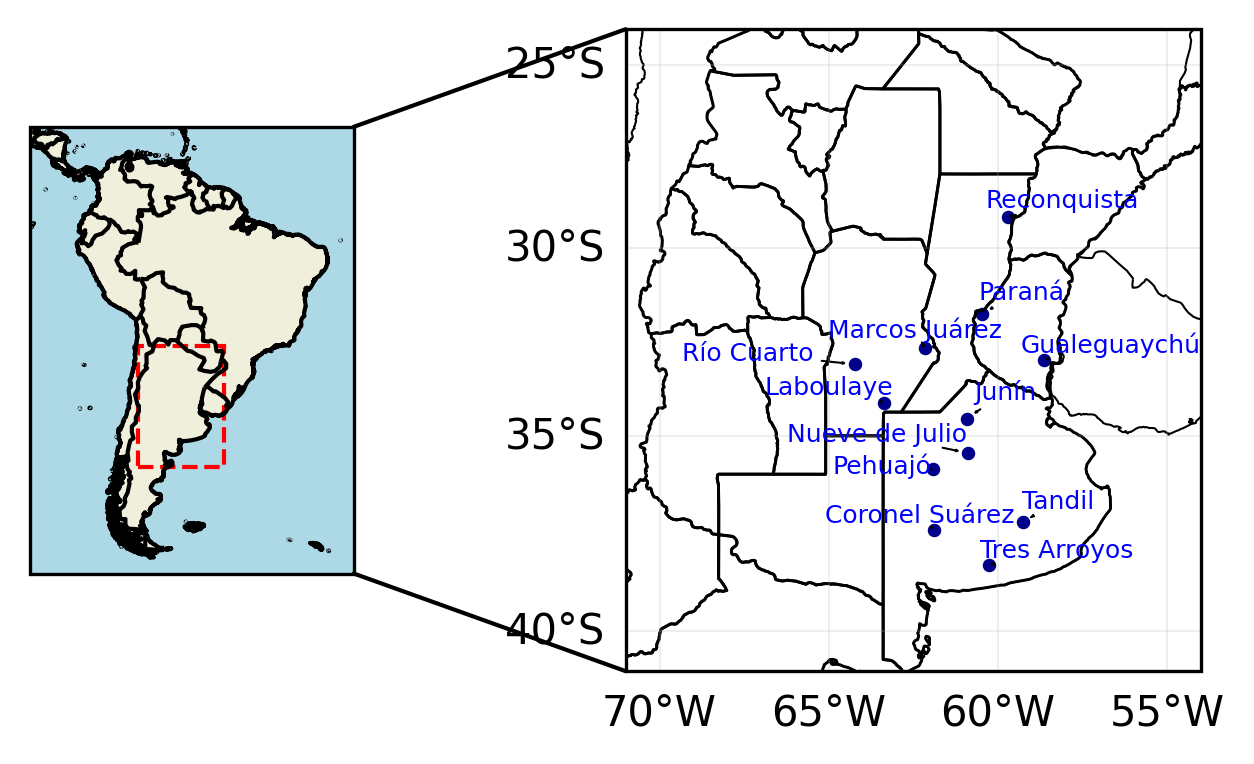

In [6]:
fig = plt.figure(    constrained_layout = True,
                dpi=300)
spec = gridspec.GridSpec(ncols=3,nrows=3, figure = fig)
ax0 = fig.add_subplot(spec[1,0],
                      projection= ccrs.Miller())

ax = fig.add_subplot(spec[:,1:-1],
                      projection= ccrs.Miller())

#add features
ax0.coastlines(resolution='10m')
ax0.set_extent([-90,-30,-58,17], crs = ccrs.PlateCarree())
ax0.add_feature(cfeature.BORDERS)
ax0.add_feature(cfeature.LAND)
ax0.add_feature(cfeature.OCEAN,facecolor=("lightblue"))

# add red squared
rect = Rectangle(
    (-70, -43),      # (lon_min, lat_min)
    16,               # width = -72 - (-74)
    20,              # height = -24 - (-43)
    fill=False,
    edgecolor='red',
    linestyle='--',
    linewidth=1,
    transform=ccrs.PlateCarree()  # if using Cartopy
)
ax0.add_patch(rect)


# add connections
# upper-right of ax0 -> upper-left of ax1
con1 = ConnectionPatch(
    xyA=(1, 1), coordsA="axes fraction", axesA=ax0,
    xyB=(0, 1), coordsB="axes fraction", axesB=ax,
)

# bottom-right of ax0 -> bottom-left of ax1
con2 = ConnectionPatch(
    xyA=(1, 0), coordsA="axes fraction", axesA=ax0,
    xyB=(0, 0), coordsB="axes fraction", axesB=ax,
)

fig.add_artist(con1)
fig.add_artist(con2)


# Now we add the information from the locations 
create_base_map(ax = ax)



texts = []
for row in data_locations.itertuples():
    ax.scatter(
        row.longitude,
        row.latitude,
        color="darkblue",
        s=5,
        transform=ccrs.PlateCarree()
    )

    texts.append(
        ax.text(
            row.longitude,
            row.latitude,
            row.location,
            color="blue",
            fontsize=6,
            ha="center",
            va="bottom",
            transform=ccrs.PlateCarree()
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=0.5
    )
)



plt.savefig("Plots/locations.png",dpi=300,bbox_inches='tight')

# Cleaning process

We prepare the data for later use:

 - Get management data, sowing period and nitrogen
 - order locations and initial sw, with categorical data

In [7]:
# SPlit management into "period", "planting date" and "nitrogen"
split_strings = df['management'].str.split('-')
df["management_period"] = [ split_strings[i][1] for i in range (len(split_strings)) ]
df["management_planting_date"] = [ split_strings[i][2] for i in range (len(split_strings)) ]
df["management_nitrogen"] = [ split_strings[i][3] for i in range (len(split_strings)) ]




# reorder categories!!
order = ["Reconquista","Paraná","Gualeguaychú","Río Cuarto","Marcos Juárez",
         "Laboulaye","Junín","Pehuajó","Nueve de Julio","Coronel Suárez","Tandil","Tres Arroyos"]
df['location'] = df["location"].astype("category")
df['location'] = df['location'].cat.reorder_categories(order)

# COnvert Soil water into a categorical variable
df['initial_sw'] = df["initial_sw"].str.capitalize()
df['initial_sw'] = df['initial_sw'].astype("category")
df['initial_sw'] = df['initial_sw'].cat.reorder_categories(["Low","Mid","High"])

For each stations there is
- A set of 2 managements
- Between 3 and 5 soil families and series
- **3 initial water conditions**
- **57 years**

# Some climatology

We first make a boxplot for each location. We compare yield distribution for each initial SW and for each management period (short and long). Each boxplot contains a total of 57 multiplied 3 to 6 soilseries/family combinations

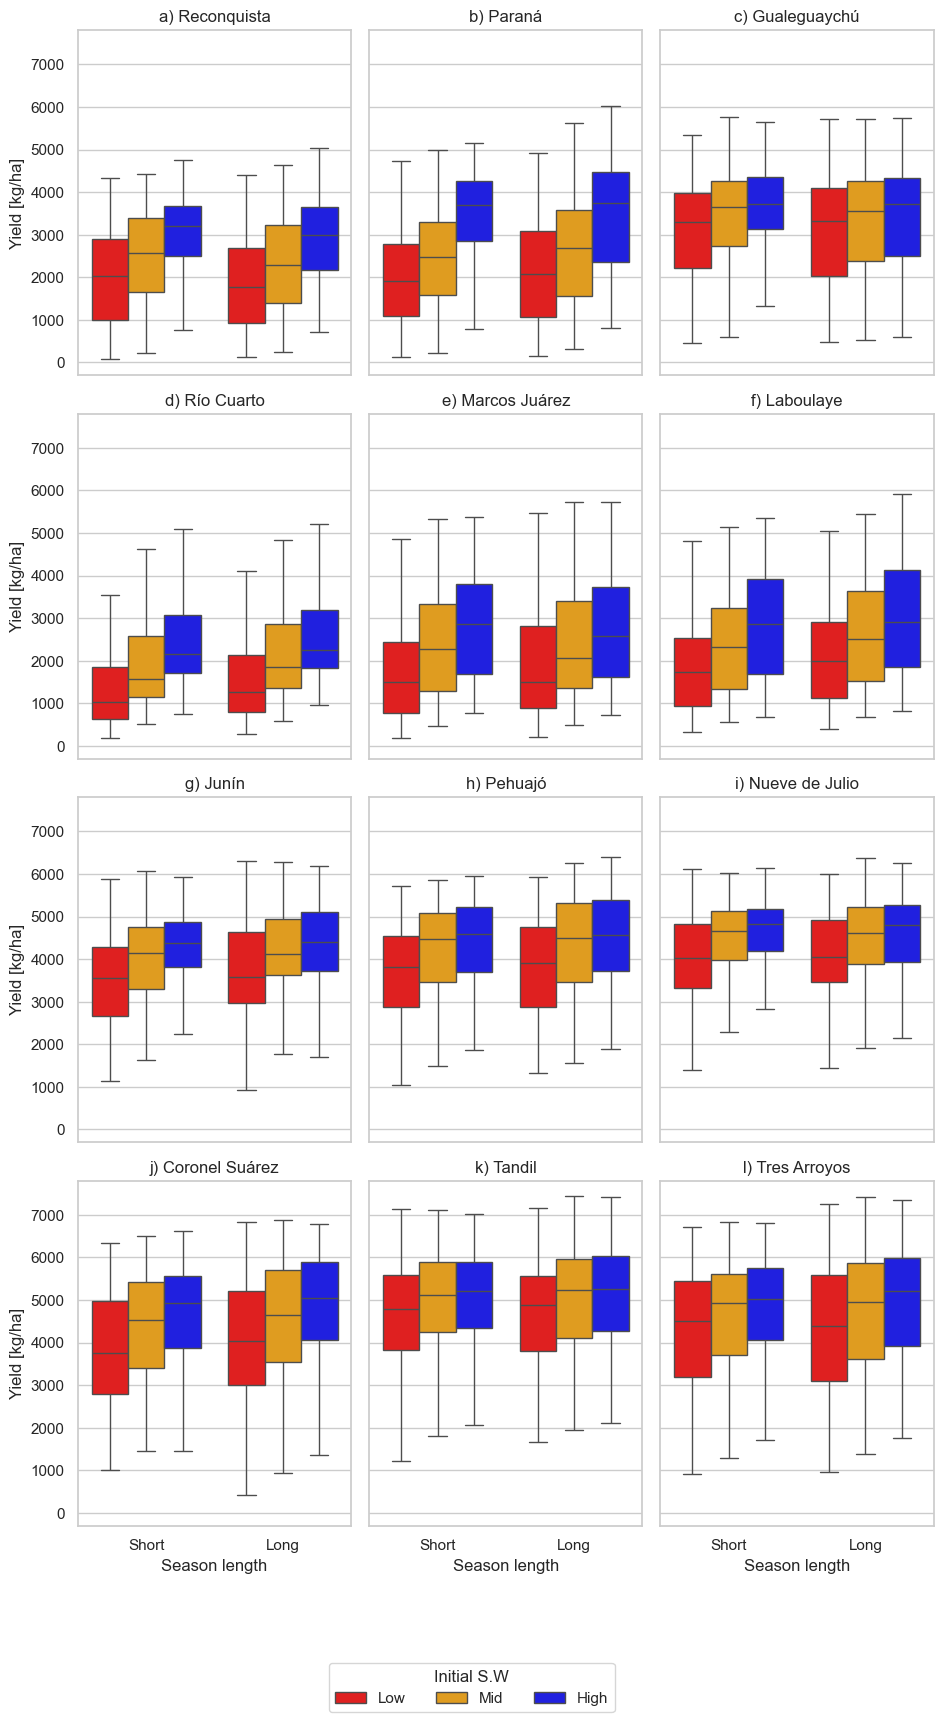

In [8]:
g = facet_plot(
    df,
    sns.boxplot,
    showfliers = False,
    x="management_period",
    y="yield_kg_ha",
    height= 4,
    aspect = 0.8,
    hue="initial_sw",
    palette={"Low":"red","Mid":"orange","High":"blue"},
    legend_title = "Initial S.W"
)


g.set(xlabel = "Season length",
      ylabel="Yield [kg/ha]")
g.set_xticklabels(["Short","Long"])

plt.savefig("plots/boxplot_comparison_sw_management.png", dpi=300, bbox_inches="tight")

# Group and filter data
- Long (Largo) management
- remove "mid" water

In [9]:
df_new = df[(df["management_period"]=="Largo ") & (df["initial_sw"]!="Mid")].copy()
df_new['initial_sw'] = df_new['initial_sw'].cat.set_categories(["High","Low"]).copy()

### Group by
df_new = df_new.groupby(["location","latitude","longitude","initial_sw","year",
                        "management_period","management_planting_date"])["yield_kg_ha"].mean().reset_index().dropna()

### series 

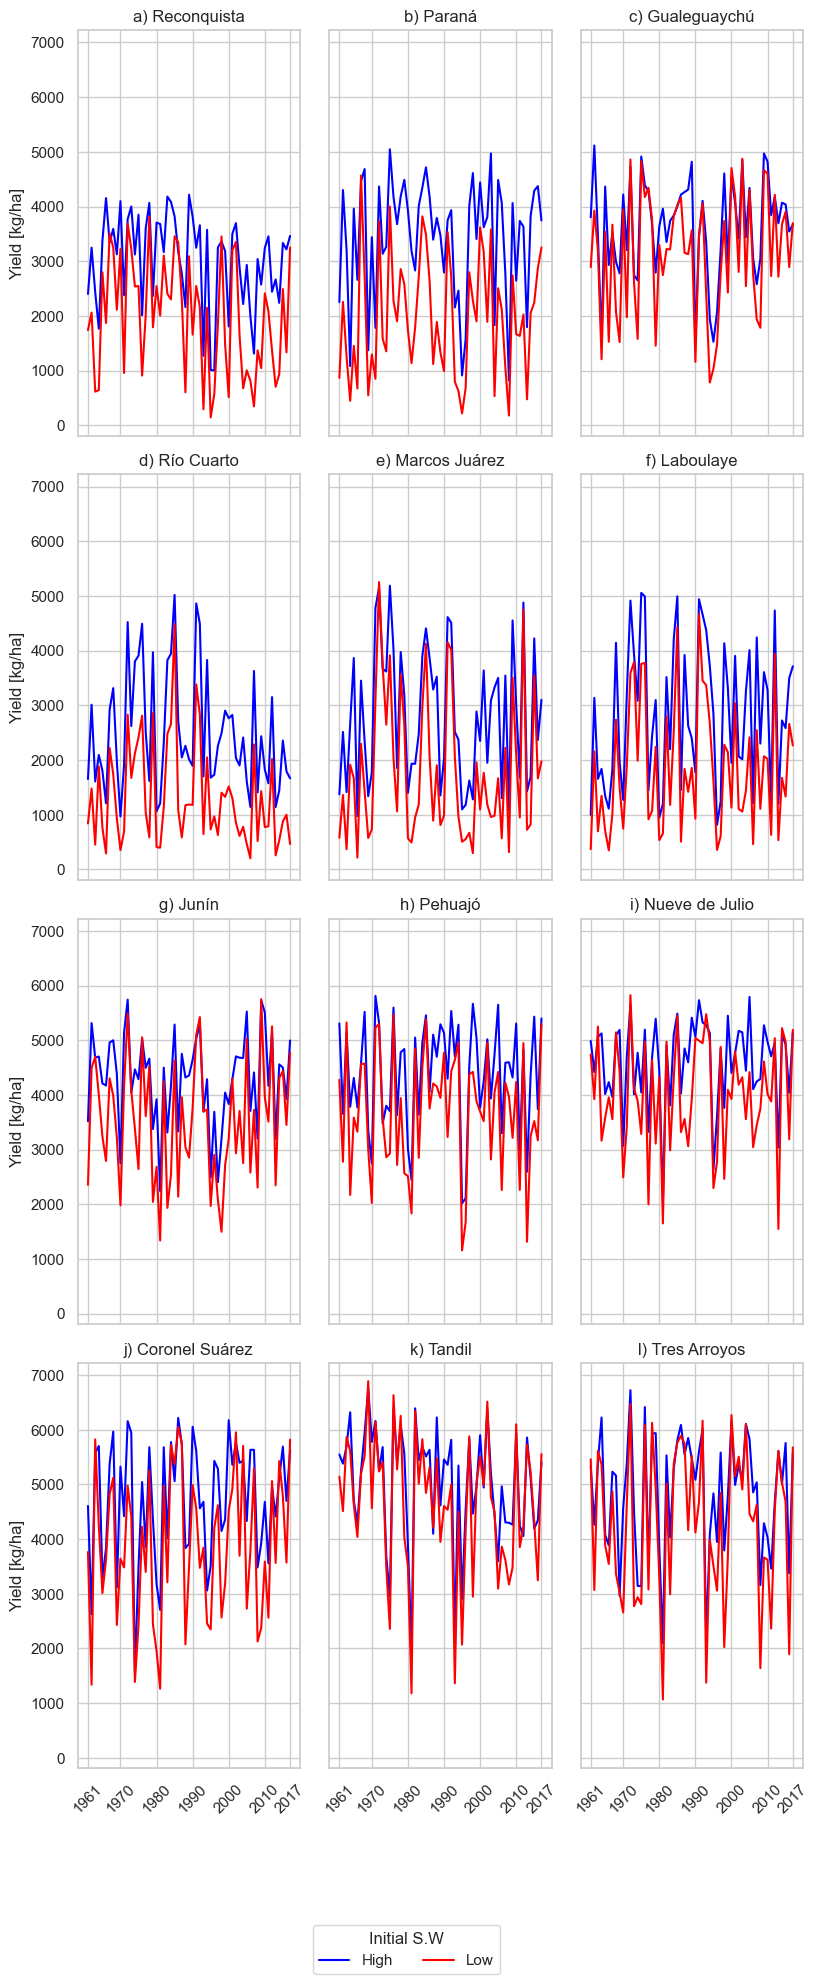

In [10]:
g = facet_plot(
    df_new,
    sns.lineplot,
    x="year",
    y="yield_kg_ha",
        height= 234 /25.4/2,
    aspect = 0.6,
    hue="initial_sw",
    palette={"Low":"red","High":"blue"},
    legend_title = "Initial S.W"
)


g.set(xlabel = "",ylabel = "Yield [kg/ha]",
    xticks = [1961,1970,1980,1990,2000,2010,2017],
    )
g.set_xticklabels([1961,1970,1980,1990,2000,2010,2017],rotation=45)

plt.savefig("Plots/series_sw.png",dpi=300,bbox_inches='tight')

### Trends

In [11]:
# Plot in map the average and differences
df_new_corr = df_new.groupby(["location","initial_sw"])[["year","yield_kg_ha"]].corr().reset_index()

print(df_new_corr[ np.abs(df_new_corr["year"]).between(0.26,1, inclusive = "neither") ] )

      location initial_sw      level_2      year  yield_kg_ha
3  Reconquista        Low  yield_kg_ha -0.267946          1.0


**Only two series have significan trend, but still below |0.3|**
# Difference between water condition average

In [12]:
# Group and calculate general statistics
df_new_average = (
    df_new.groupby(["location","latitude","longitude","initial_sw"])
    .agg(
        yield_mean=("yield_kg_ha", "mean"),
        yield_sd=("yield_kg_ha", "std"),
         yield_count=("yield_kg_ha", "count"),
    )).dropna().reset_index()
df_new_average["rel_std"] = df_new_average["yield_sd"]/df_new_average["yield_mean"]


In [13]:
# Pivot data, to have the average of each water condition in columns
df_new_average_pivot = df_new_average.pivot(index=["location","latitude","longitude"],
                                            columns = "initial_sw", values = "yield_mean").reset_index()
# Substract average under low conditions to the high conditions
df_new_average_pivot["difference"] = df_new_average_pivot["High"] - df_new_average_pivot["Low"]

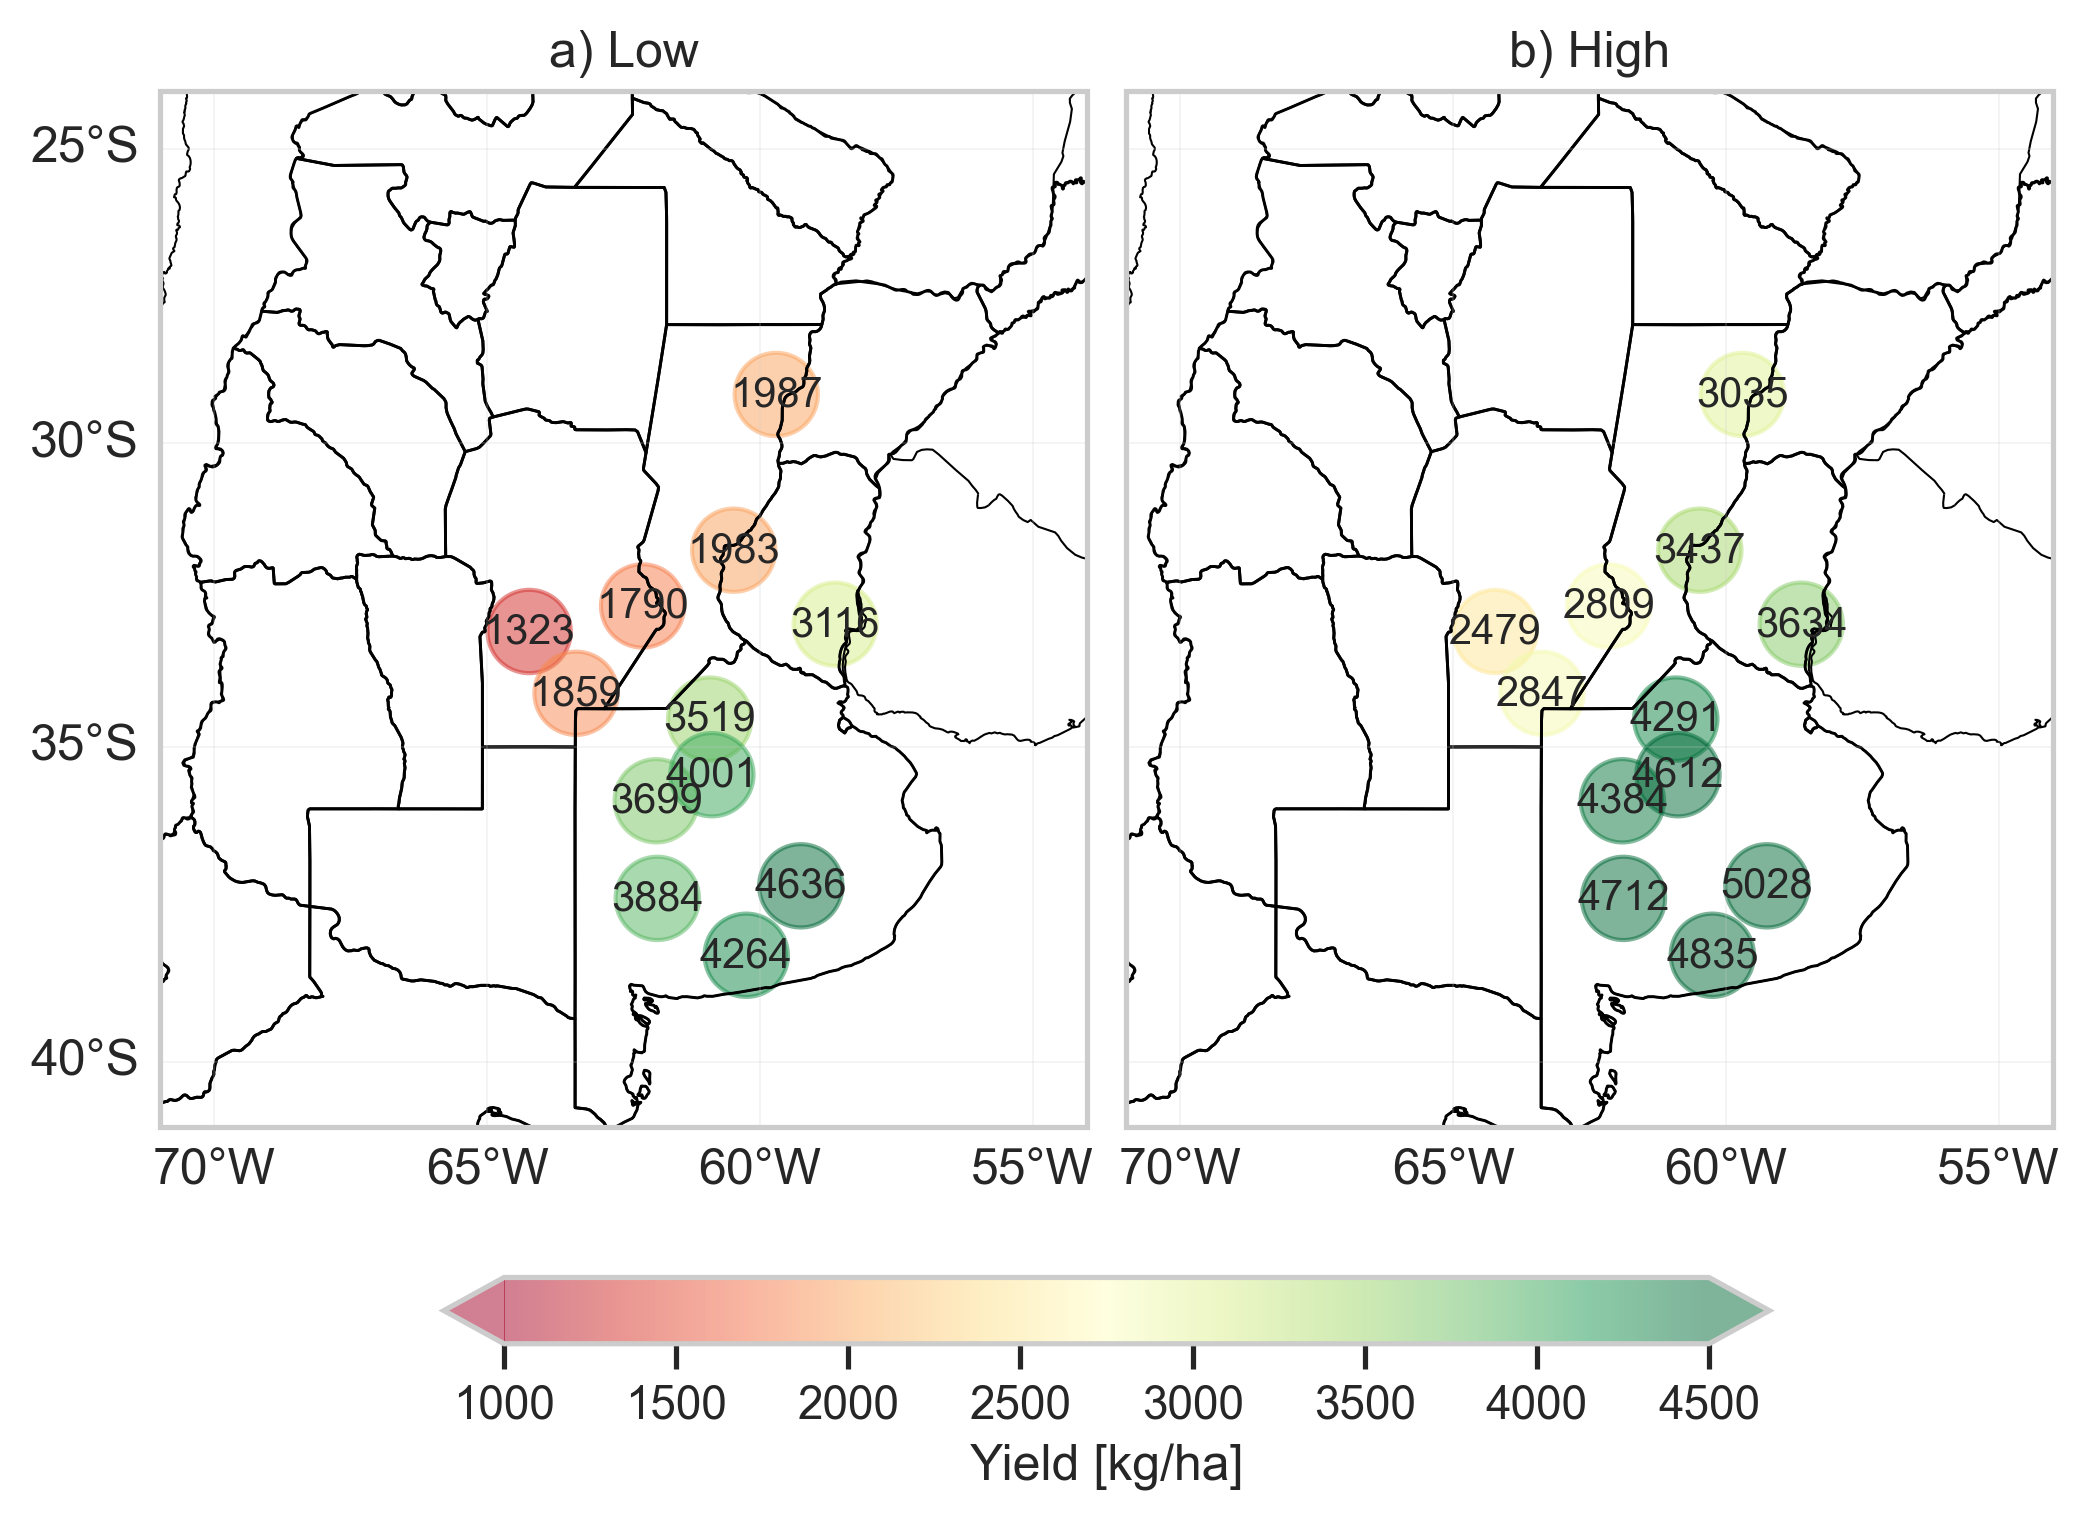

In [14]:
map_plot(
    longitude = df_new_average_pivot["longitude"],
    latitude = df_new_average_pivot["latitude"],
    colors = [df_new_average_pivot["Low"],
                 df_new_average_pivot["High"]],
    texts = [df_new_average_pivot["Low"].astype(int),
             df_new_average_pivot["High"].astype(int)],
    titles = ["a) Low","b) High"],
    cmap = "RdYlGn",
    cbar_title = "Yield [kg/ha]",
    vmin = 1000,
    vmax = 4500,
    extend="both",
    cbar_ticks=None,
    cbar_ticklabels=None,
)

plt.savefig("Plots/map_average_yield_sw.png", dpi =300,bbox_inches='tight')

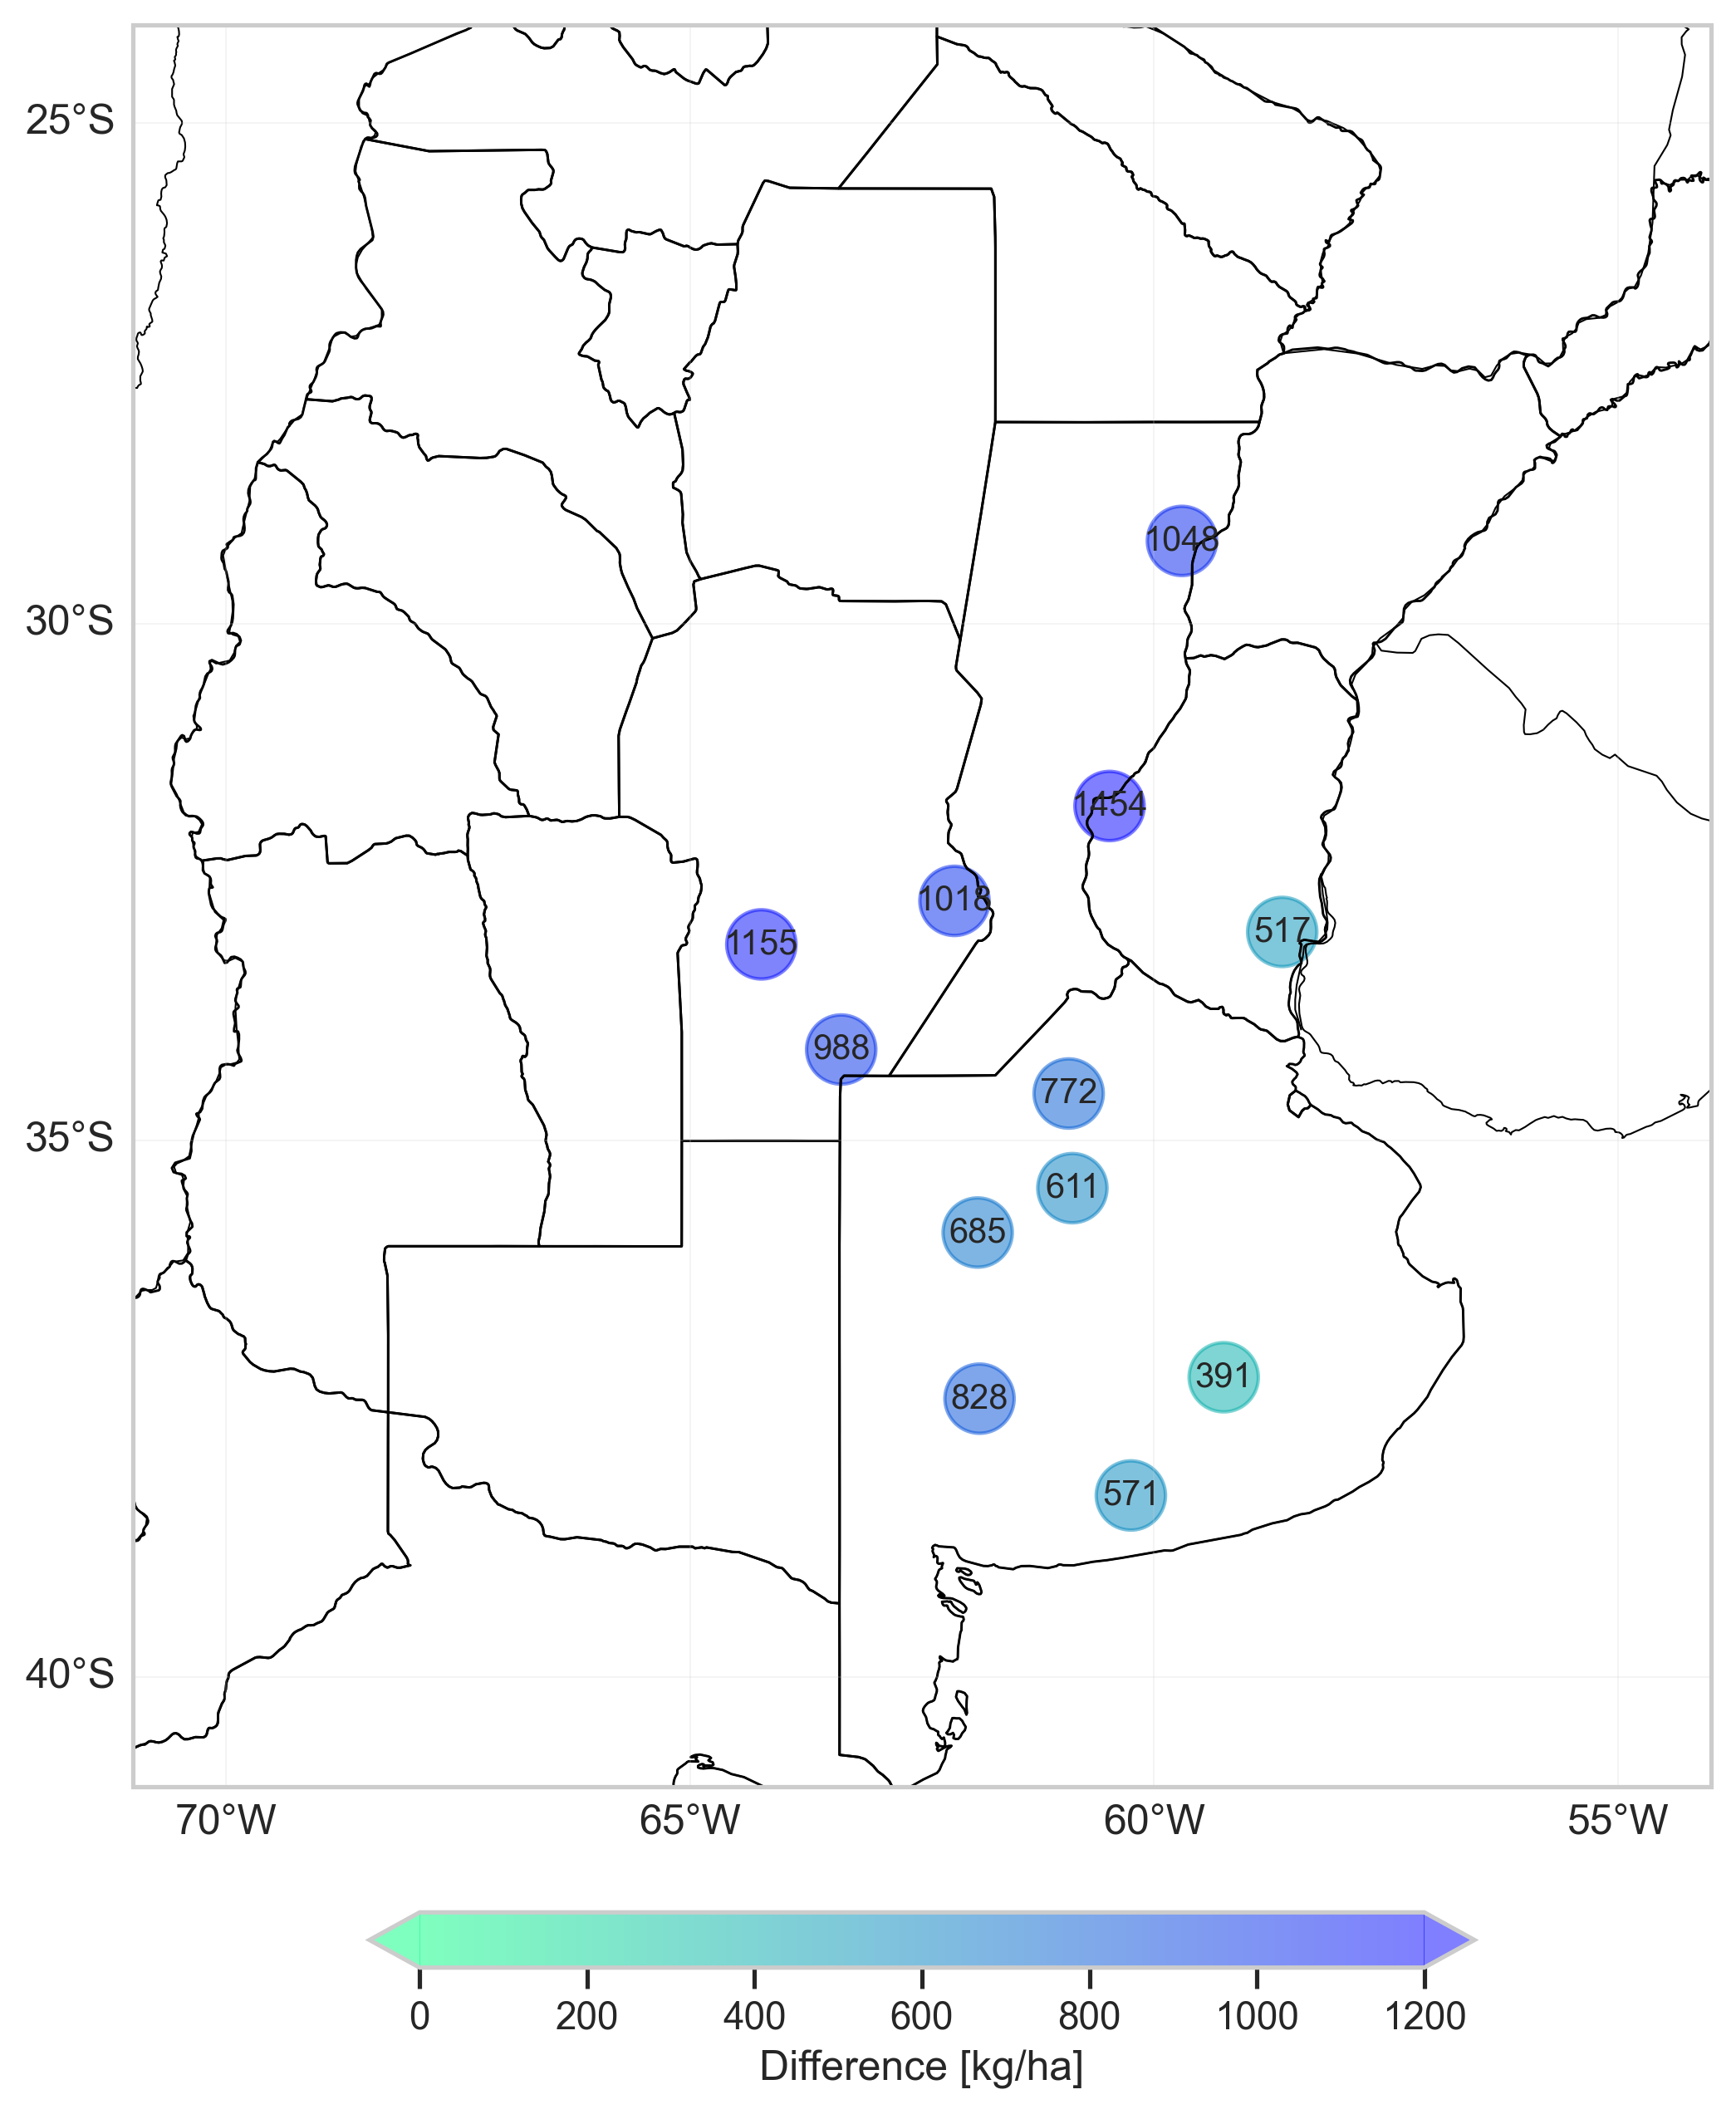

In [15]:
map_plot(
    longitude = df_new_average_pivot["longitude"],
    latitude = df_new_average_pivot["latitude"],
    colors = [df_new_average_pivot["difference"]],
    texts = [df_new_average_pivot["difference"].astype(int)],
    cmap = "winter_r",
    titles = None,
    cbar_title = "Difference [kg/ha]",
    vmin = 0,
    vmax = 1200,
    extend="both",
    cbar_ticks=None,
    cbar_ticklabels=None,
)

plt.savefig("Plots/map_difference_average_yield_sw.png", dpi =300,bbox_inches='tight')

# Map Planting date


In [16]:
dftoplot = df_new.groupby(["location","latitude","longitude","management_planting_date"]).count()
dftoplot = dftoplot[dftoplot!=0].dropna().reset_index()

In [17]:
julian_map = {
    " 15 May ": 135,
    " 25 May ": 145,
    " 1 Jun ": 152,
    " 5 Jun ": 156,
    " 20 Jun ": 171,
    " 25 Jun ": 176,
    " 1 Jul ": 182,
}
dftoplot["planting_julian_day"] = dftoplot["management_planting_date"].apply(lambda x: julian_map[x])

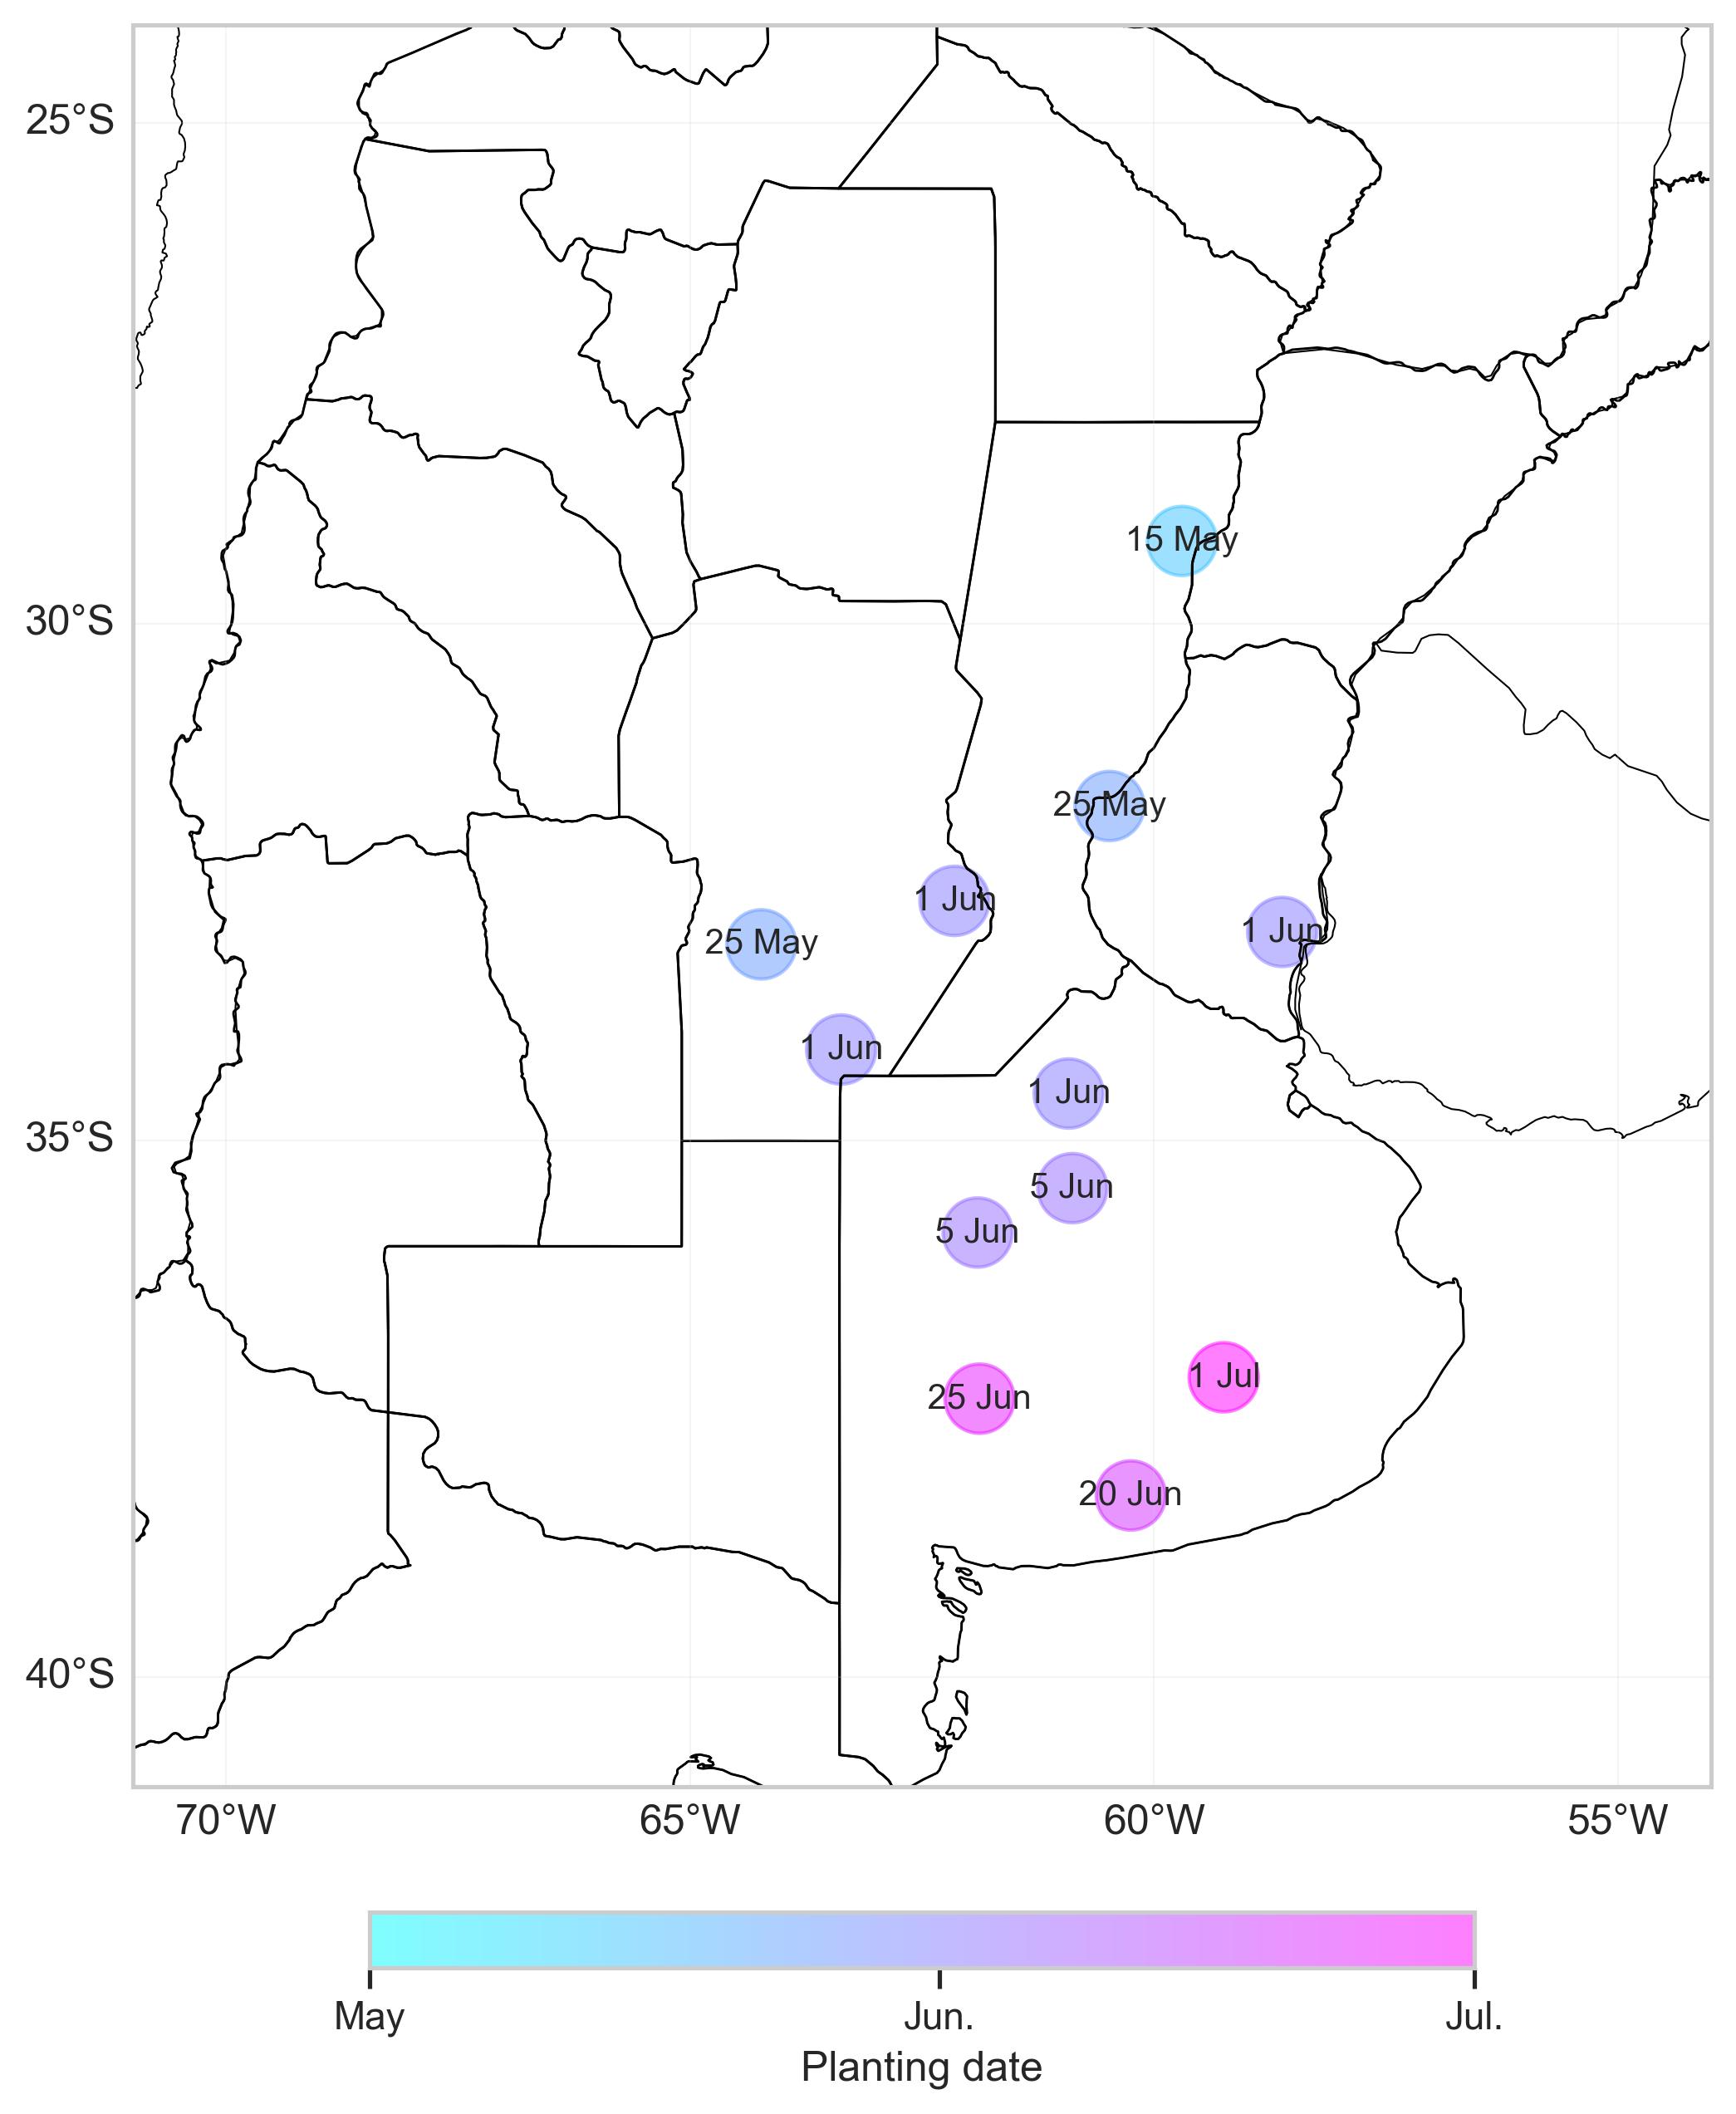

In [18]:
map_plot(
    longitude = dftoplot["longitude"],
    latitude = dftoplot["latitude"],
    colors = [dftoplot["planting_julian_day"]],
    texts = [dftoplot["management_planting_date"]],
    cmap = "cool",
    titles = None,
    cbar_title = "Planting date",
    vmin = 120,
    vmax = 182,
    cbar_ticklabels= ["May","Jun.","Jul."],
    cbar_ticks =  [120,152,182],
    extend=None,
)

plt.savefig("Plots/map_planting_date.png", dpi =300,bbox_inches='tight')

# every single soil/type

In [19]:
for location, g1 in df.groupby("location"):
    managements = sorted(g1["management"].unique())
    print(location + f" | {' / '.join(managements)}")
    for family, g2 in g1.groupby("soil_family"):
        #print(f"  ├── {family}")
        series = sorted(g2["soil_series"].unique()) 
        print(f"  ├──  {family}" +  f" | {' / '.join(series)}")
        #for series, g3 in g2.groupby("soil_series"):
        #    print(f"  │   ├── {series}")

Reconquista | Intermedio-Corto - 15 Jun - 100N / Intermedio-Largo - 15 May - 100N
  ├──  Argialbol argiácuico | 150 PT 48
  ├──  Argiudol típico | 150 PT 29
  ├──  Argiudol vértico | 120 PT 35
  ├──  Artiudol ácuico | 150 PT 11
  ├──  Udipsament thapto árgico | 150 PT 22 / 180 PT 33
Paraná | Intermedio-Corto - 20 Jun - 120N / Intermedio-Largo - 25 May - 120N
  ├──  Argiudol vértico | Damasio
  ├──  Argiudol ácuico | Tezanos Pinto
  ├──  Peludert argílico crómico | El Triángulo
Gualeguaychú | Intermedio-Corto - 25 Jun - 120N / Intermedio-Largo - 1 Jun - 120N
  ├──  Argiudol vértico | La Blanqueada
  ├──  Argiudol ácuico | Arroyo Animal
  ├──  Hapludol fluventico | Aldea Asunción
  ├──  Pelludert árgico | La Concordia
Río Cuarto | Intermedio-Corto - 20 Jun - 130N / Intermedio-Largo - 25 May - 130N
  ├──  Argiustol udorthentico | Alejo Ledesma
  ├──  Haplustol típico | General Dehesa
  ├──  Haplustol éntico | Olaeta
  ├──  Haplustol údico | Leguizamón
Marcos Juárez | Intermedio-Corto - 20

# Save data for the other scripts

In [20]:
df_new.to_csv("data/processed_data/yield_averaged_across_management_soil.csv", index=False)